In [1]:
from swo_lanczos_2023_09_08 import output_dir
from misc_utils import read_jsonl_to_df
import seaborn as sns
import matplotlib.pyplot as plt

2023-09-11 14:48:19.624 | DEBUG    | lattice_symmetries:__init__:50 - Initializing Haskell runtime...
2023-09-11 14:48:19.737 | DEBUG    | lattice_symmetries:__init__:52 - Initializing Chapel runtime...
2023-09-11 14:48:19.879 | DEBUG    | lattice_symmetries:__init__:54 - Setting Python exception handler...
set_python_exception_handler ...


In [2]:
overlaps_df = read_jsonl_to_df(output_dir.glob("./*/overlaps.jsonl")).fillna({'epochs': 100})
losses_df = read_jsonl_to_df(output_dir.glob("./*/losses.jsonl")).assign(
    global_epoch=lambda df: df["epoch"] + df["iteration"] * (df["epoch"].max() + 1)
)

In [3]:
def to(type_, cols):
    def wrapper(df):
        df = df.copy()
        if isinstance(cols, str):
            cols_ = [cols]
        else:
            cols_ = cols
        for col in cols_:
            df[col] = df[col].astype(type_)
        return df
    return wrapper

In [4]:
# sns.relplot(
#     losses_df.query(
#         'lattice == "KagomeLattice2x3" and n_samples == 1000'
#     ).fillna({'energy_baseline': -1}).pipe(to(str, 'energy_baseline')),
#     x="global_epoch",
#     y="loss",
#     hue="energy_baseline",
#     kind="line",
# )

In [5]:
overlaps_df.columns

Index(['iteration', 'initial_ground_state_overlap_train',
       'initial_ground_state_overlap_test',
       'target_ground_state_overlap_train', 'new_ground_state_overlap_train',
       'new_ground_state_overlap_test', 'alpha', 'run', 'mode', 'n_samples',
       'lattice', 'energy_baseline', 'n_spins'],
      dtype='object')

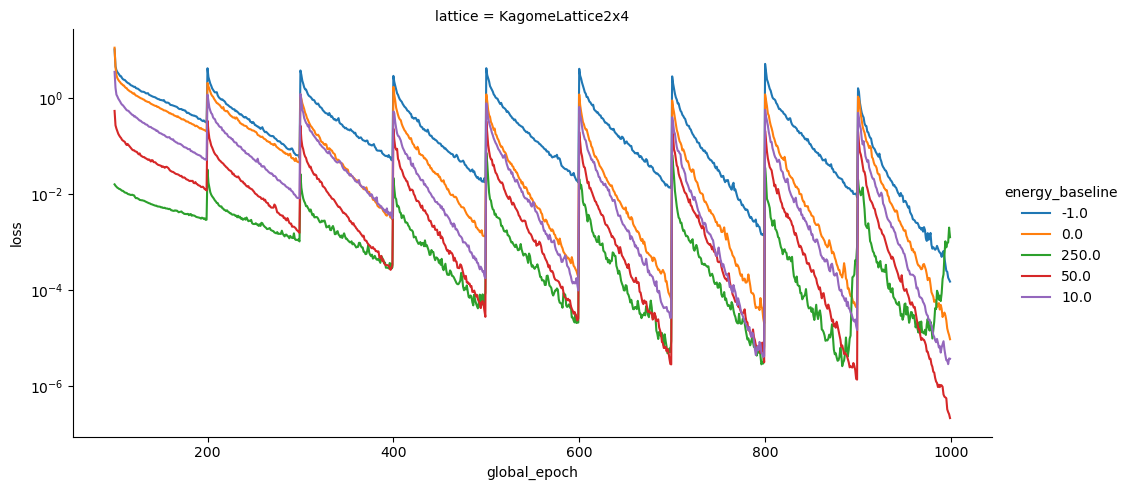

In [6]:
sns.relplot(
    losses_df.fillna({"energy_baseline": -1})
    .query("n_samples == 1000 and n_spins == 24 and iteration > 0 and iteration < 10")
    .assign(global_epoch=lambda df: df["epoch"] + df["iteration"] * (df["epoch"].max() + 1))
    .pipe(to(str, "energy_baseline")),
    x="global_epoch",
    y="loss",
    kind="line",
    aspect=2,
    hue="energy_baseline",
    row="lattice",
).set(yscale="log")

In [7]:
overlaps_df.assign(
        new_ground_state_overlap_test_smoothed=lambda df: df.groupby(
            ["lattice", "n_samples", "energy_baseline"]
        )["new_ground_state_overlap_test"].transform(
            lambda x: x.rolling(window=30, center=True).mean()
        )
    ).pipe(to(str, ["energy_baseline", "n_samples"]))

,iteration,initial_ground_state_overlap_train,initial_ground_state_overlap_test,target_ground_state_overlap_train,new_ground_state_overlap_train,new_ground_state_overlap_test,alpha,run,mode,n_samples,lattice,energy_baseline,n_spins,new_ground_state_overlap_test_smoothed
0,0,0.450045,0.450546,0.757403,0.766306,0.701641,-0.8675,0,lanczos,5000,KagomeLattice2x3,None,18,NaN
1,1,0.784395,0.686305,0.931152,0.910342,0.772314,-0.568537,0,lanczos,5000,KagomeLattice2x3,None,18,NaN
2,2,0.890981,0.773129,0.964974,0.958913,0.792415,-0.450472,0,lanczos,5000,KagomeLattice2x3,None,18,NaN
3,3,0.948075,0.803268,0.979713,0.974180,0.785305,-0.403186,0,lanczos,5000,KagomeLattice2x3,None,18,NaN
4,4,0.958989,0.808973,0.978570,0.978335,0.784315,-0.340399,0,lanczos,5000,KagomeLattice2x3,None,18,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19038,495,0.953342,0.508047,0.956448,0.956290,0.510342,None,0,power,1000,KagomeLattice2x4,10.0,24,NaN
19039,496,0.953107,0.526618,0.955398,0.955307,0.525938,None,0,power,1000,KagomeLattice2x4,10.0,24,NaN
19040,497,0.958323,0.534458,0.960406,0.960600,0.521146,None,0,power,1000,KagomeLattice2x4,10.0,24,NaN
19041,498,0.952270,0.533185,0.957571,0.957626,0.533710,None,0,power,1000,KagomeLattice2x4,10.0,24,NaN


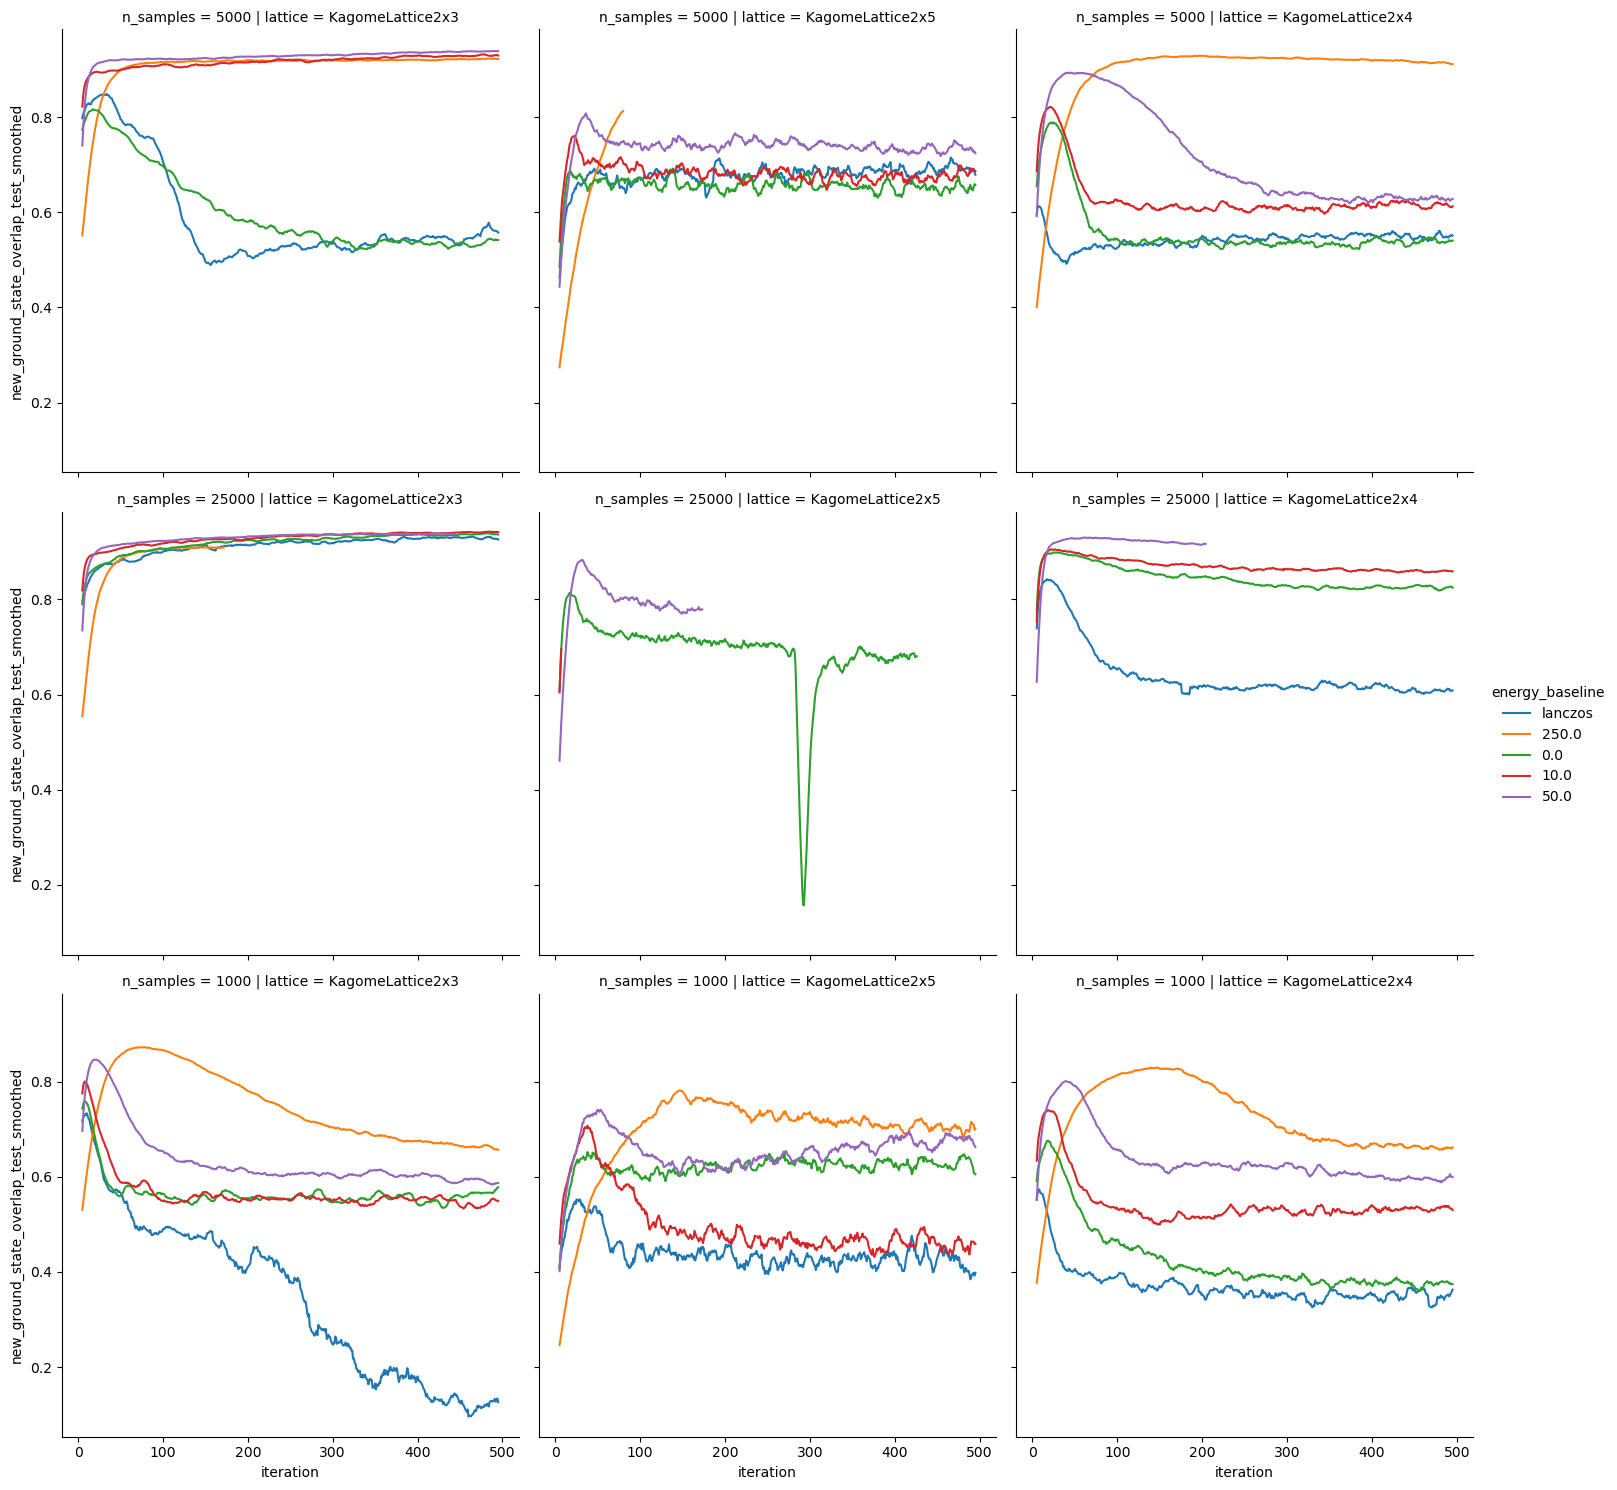

In [8]:
sns.relplot(
    data=overlaps_df.fillna({"energy_baseline": 'lanczos'})
    .assign(
        new_ground_state_overlap_test_smoothed=lambda df: df.groupby(
            ["lattice", "n_samples", "energy_baseline"]
        )["new_ground_state_overlap_test"].transform(
            lambda x: x.rolling(window=10, center=True).mean()
        )
    )
    .pipe(to(str, ["energy_baseline", "n_samples", "lattice"])),
    x="iteration",
    y="new_ground_state_overlap_test_smoothed",
    hue="energy_baseline",
    col="lattice",
    row="n_samples",
    kind="line",
)

In [12]:
overlaps_df.query("energy_baseline == 50").groupby(["n_spins", "n_samples"])[
    "new_ground_state_overlap_test"
].max()

n_spins  n_samples
18       1000         0.851334
         5000         0.941139
         25000        0.940975
24       1000         0.809466
         5000         0.900007
         25000        0.934127
30       1000         0.777967
         5000         0.828169
         25000        0.906584
Name: new_ground_state_overlap_test, dtype: float64

<Axes: xlabel='n_spins', ylabel='new_ground_state_overlap_test'>

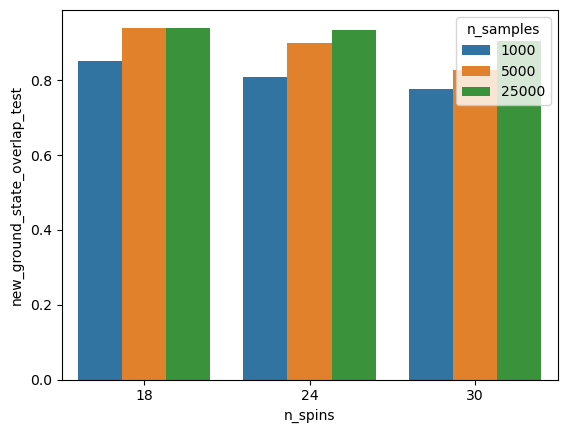

In [10]:
sns.barplot(
    overlaps_df.query('energy_baseline == 50').groupby(["n_spins", "n_samples"])['new_ground_state_overlap_test'].max().reset_index(),
    x='n_spins',
    hue='n_samples',
    y='new_ground_state_overlap_test')


In [11]:
sns.relplot(
    data=overlaps_df.fillna({"energy_baseline": 'lanczos'})
    .assign(
        new_ground_state_overlap_test_smoothed=lambda df: df.groupby(
            ["lattice", "n_samples", "energy_baseline"]
        )["new_ground_state_overlap_test"].transform(
            lambda x: x.rolling(window=1, center=True).mean()
        )
    )
    .pipe(to(str, ["energy_baseline", "n_samples", "epochs"])),
    x="iteration",
    y="new_ground_state_overlap_test_smoothed",
    hue="epochs",
    col="energy_baseline",
    row="n_samples",
    kind="line",
)

KeyError: 'epochs'

In [ ]:
overlaps_df

,iteration,initial_ground_state_overlap_train,initial_ground_state_overlap_test,target_ground_state_overlap_train,new_ground_state_overlap_train,new_ground_state_overlap_test,alpha,run,mode,n_samples,lattice,energy_baseline,n_spins,epochs
0,0,0.460177,0.451269,0.777352,0.777922,0.628440,-0.863657,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
1,1,0.688698,0.622368,0.888058,0.887952,0.644334,-0.715098,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
2,2,0.720192,0.672630,0.879989,0.881688,0.667056,-0.549112,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
3,3,0.822422,0.686204,0.939404,0.940045,0.631306,-0.726745,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
4,4,0.809950,0.695011,0.927723,0.926465,0.685047,-0.539695,0,lanczos,1000,KagomeLattice2x3,None,18,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782,495,0.818403,0.199005,0.758271,0.758354,0.174930,-0.663930,0,lanczos,1000,KagomeLattice2x3,None,18,100.0
783,496,0.731347,0.189546,0.819627,0.819642,0.187885,-0.524637,0,lanczos,1000,KagomeLattice2x3,None,18,100.0
784,497,0.863109,0.194170,0.659473,0.659463,0.171711,-0.880196,0,lanczos,1000,KagomeLattice2x3,None,18,100.0
785,498,0.313704,0.186600,0.897028,0.897049,0.178817,-0.743507,0,lanczos,1000,KagomeLattice2x3,None,18,100.0


In [ ]:
# (ggplot(overlaps_df.dropna(subset=['energy_baseline']), aes(x='iteration', y='new_ground_state_overlap_test', color='energy_baseline'))
#     + geom_point() + geom_smooth(method='loess')
#     + facet_grid('n_samples ~ lattice') + theme_minimal())

In [ ]:
# sns.relplot(
#     overlaps_df.query("lattice == 'KagomeLattice2x3'").pipe(to_cat("energy_baseline")),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="energy_baseline",
#     kind="line",
#     row="lattice",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')


In [ ]:
# sns.relplot(
#     overlaps_df.query("mode == 'power'"),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="lattice",
#     kind="line",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')
